# Customer Churn Analysis
### Problem:
As a Business and Strategy Analyst, articulating the concept of "Customer Churn" necessitates a perspective that transcends a mere operational metric. Customer churn represents the **"value leakage"** within your business model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from matplotlib.pyplot import title
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df = df.drop(["customerID"], axis = 1)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [6]:
df.shape

(7043, 20)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

## EDA

In [9]:
df.isna().any()

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [10]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.iloc[df["TotalCharges"]==" "]=np.nan

In [13]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
TotalCharges = df[['TotalCharges']]
data = imputer.fit_transform(TotalCharges)
df[['TotalCharges']] = data

In [14]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Class-imbalanced Data
As you can see Churn distribution is imbalanced and you must make a decision which strategy to choose
#### Data-Level Methods
Changing Data for eliminating
- **Oversampling**
  - Random Oversampling
  - SMOTE
  - Borderline-SMOTE
  - ADASYN
  - KMeans-SMOTE

- **Undersampling**
  - Random Undersampling
  - Tomek Links
  - NearMiss
  - Edited Nearest Neighbours (ENN)
- **Hybrid**
  - SMOTE + Tomek Links
  - SMOTE + ENN

#### Algorithm-Level Methods
- class_weight='balanced'<br>
For instance, this models SGDClassifier، LogisticRegression، LinearSVC
- Cost-sensitive learning
- Weighted loss
- Focal Loss
- Threshold Moving

#### Model
- XGBoost
- LightGBM
- CatBoost
- Balanced Random Forest
- EasyEnsemble

#### Ensemble Methods
- Bagging
- Boosting
- Balanced Bagging
- EasyEnsemble
- RUSBoost

#### Change Evaluation Metrics
Instead of `Accuracy` use:
- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- Matthews Correlation Coefficient (MCC)
- Balanced Accuracy

#### My Plan
`Algorithm-Level Methods` & `Model` & `Ensemble Methods`

## Churn Distribution
Almost 73.5% of customers were not churned, however 26.5% of the customers were roughly churned.<br>
You can see the result below.<br>
`Managers` must make decision is it critical or not.

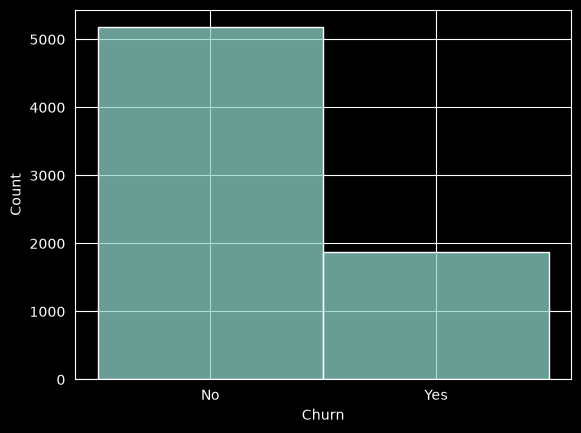

In [15]:
sns.histplot(data=y, cbar=True)
plt.show()

In [16]:
labels_ = ["Yes", "No"]
fig = go.Figure(data=go.Pie(labels=labels_, values=y.value_counts(), name='Churn'))
# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)
fig.update_layout(
    title_text="Churn Distributions",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Churn', x=0.5, y=0.5, font_size=20, showarrow=False)])
fig.show()

## Churn Distribution on Gender

In [17]:
female_No = df["Churn"][df["Churn"] == "No"].groupby(by = df.gender).count()["Female"]
male_No = df["Churn"][df["Churn"] == "No"].groupby(by = df.gender).count()["Male"]

female_Yes = df["Churn"][df["Churn"] == "Yes"].groupby(by = df.gender).count()["Female"]
male_Yes = df["Churn"][df["Churn"] == "Yes"].groupby(by = df.gender).count()["Male"]

churn_No = df["Churn"][df["Churn"] == "No"].count()
churn_Yes = df["Churn"][df["Churn"] == "Yes"].count()

churn_labels=["Churn: Yes", "Churn: No"]
churn_values = [churn_Yes, churn_No]

gender_labels = ["Female", "Male", "Female", "Male"]
gender_values = [female_Yes, male_Yes, female_No, male_No]

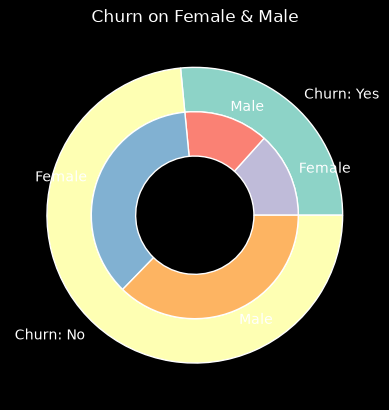

In [18]:
fig, ax = (plt.subplots())

size = 0.3

ax.pie(
    churn_values,
    labels=churn_labels,
    radius=1,
    wedgeprops=dict(width=size, edgecolor='w')
)

ax.pie(
    gender_values ,
    labels=gender_labels,
    radius=1-size,
    wedgeprops=dict(width=size, edgecolor='w')
)

ax.set(aspect="equal", title='Churn on Female & Male')
plt.show()

In [19]:
print("Churn on Female & Male\n")
female_No_ratio = 100 * female_No / churn_No
male_No_ratio = 100 * male_No / churn_No

print(f"{female_No_ratio:.2f}% of unchurned Customers are female.")
print(f"{male_No_ratio:.2f}% of unchurned Customers are male.")
print()

female_Yes_ratio = 100 * female_Yes / churn_Yes
male_Yes_ratio = 100 * male_Yes / churn_Yes

print(f"{female_Yes_ratio:.2f}% of churned Customers are female.")
print(f"{male_Yes_ratio:.2f}% of churned Customers are male.")
print()

churn_No_by_female = 100 * female_No/(female_No + female_Yes)
churn_Yes_by_female = 100 * female_Yes/(female_No + female_Yes)

print(f"{churn_No_by_female:.2f}% of female are NOT churned.")
print(f"{churn_Yes_by_female:.2f}% of female are churned.")
print()

churn_No_by_male = 100 * male_No/(male_No + male_Yes)
churn_Yes_by_male = 100 * male_Yes/(male_No + male_Yes)

print(f"{churn_No_by_male:.2f}% of male are NOT churned.")
print(f"{churn_Yes_by_male:.2f}% of male are churned.")
print()

Churn on Female & Male

49.27% of unchurned Customers are female.
50.73% of unchurned Customers are male.

50.24% of churned Customers are female.
49.76% of churned Customers are male.

73.08% of female are NOT churned.
26.92% of female are churned.

73.84% of male are NOT churned.
26.16% of male are churned.



## Churn on Contract

In [20]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [21]:
fig = px.histogram(df, x="Churn", color = "Contract", barmode = "group", title = "<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.2)
fig.show()

## Data Cleanig

In [23]:
y = df['Churn']
X = df.drop(['Churn'], axis = 1)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)

In [63]:
print(f"ratio of yes in train set: {100 * (y_train[ y_train=="Yes" ].count() /  y_train.count()):.2f}%")
print(f"ratio of no in train set: {100 * (y_train[ y_train=="No" ].count() /  y_train.count()):.2f}%")
print()
print(f"ratio of yes in test set: {100 * (y_test[ y_test=="Yes" ].count() /  y_test.count()):.2f}%")
print(f"ratio of no in test set: {100 * (y_test[ y_test=="No" ].count() /  y_test.count()):.2f}%")


ratio of yes in train set: 26.54%
ratio of no in train set: 73.46%

ratio of yes in test set: 26.54%
ratio of no in test set: 73.46%


In [66]:
X_train

<bound method DataFrame.corr of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
3738    Male            0.0      No         No    35.0           No   
3151    Male            0.0     Yes        Yes    15.0          Yes   
4860    Male            0.0     Yes        Yes    13.0           No   
3867  Female            0.0     Yes         No    26.0          Yes   
3810    Male            0.0     Yes        Yes     1.0          Yes   
...      ...            ...     ...        ...     ...          ...   
6303  Female            0.0     Yes         No    71.0          Yes   
6227    Male            0.0      No         No     2.0          Yes   
4673  Female            1.0      No         No    25.0          Yes   
2710  Female            0.0     Yes         No    24.0          Yes   
5639    Male            0.0      No         No     6.0          Yes   

         MultipleLines InternetService       OnlineSecurity  \
3738  No phone service             DSL              